# Your first gradient

Runnable locally on CPU or on a Cloud TPU VM.

- Predict the sign and magnitude of a derivative from a local change.
- Trace the chain rule through a composed numerical function.
- Compare an analytic derivative, a finite-difference estimate, and JAX autodiff.
- Distinguish a stationary point from a minimum and repair scalar-output/input-type errors.

Imagine that you can turn one dial, and a score tells you how far you are from the result you want. Which way should you turn it? We’ll begin with the curve $f(x)=x^2$, where we can check the answer by hand. A derivative tells us how the score changes nearby; then JAX will calculate that derivative for us. You do not need to guess what the tool is doing.

## The idea

A derivative tells us how an output changes near a particular input. We can understand it before using autodiff: move the input a small amount, estimate the output change from the local slope, then compare that prediction with the function.

## Use a slope to predict a nearby change

For a separate hand calculation, let $f(x)=x^2$. At $x=3$, the derivative is $6$. Moving to $3.01$ gives a first-order prediction of $9+6(0.01)=9.06$. The exact value is $9.0601$; the small difference comes from curvature.

In the tangent figure, the tangent agrees with the curve at the selected point and has the same local slope. It need not follow the curve far away. Move the point and watch the slope change; then move only a small distance from that point to judge the linear approximation.

Autodiff computes the derivative of the operations you wrote. It does not choose a meaningful objective for you. A gradient of the wrong loss can be numerically correct, which is why later lessons check both the formula and its derivative.

### Pause and reason

Does a positive derivative mean the function value itself is positive?

<details><summary>Compare your reasoning</summary>

No. The derivative describes local change. For $f(x)=x-10$ at $x=0$, the value is $-10$ while the derivative is $1$.

</details>

## Read a slope before you compute it

Let’s start at $x=3$. If we move right by $\delta=0.01$, the score changes from $9$ to $9.0601$. That is an increase of $0.0601$. The slope predicts an increase of about $6\times0.01=0.06$, which is close.

Here $\delta$ means a small change in the input, and $f\prime(x)$ means the slope at that input. Expanding the square gives the exact change below. The term $\delta^2$ is what the straight-line approximation leaves out. As the change gets smaller, that term becomes small compared with the linear term when the slope is nonzero.

Before running the code, try a negative input. At $x=-3$, moving a little to the right reduces the score. The slope should therefore be negative. At zero, the slope is zero even though moving away in either direction increases the square.

$$
\begin{aligned}f(x+\delta)-f(x)&=2x\delta+\delta^2\\f\prime(x)&=2x\end{aligned}
$$

## Three ways to obtain a derivative

An analytic derivative comes from reasoning about the mathematical function. A finite difference approximates a derivative by evaluating the function at nearby inputs. Automatic differentiation applies derivative rules to the operations that execute in the program and composes those rules with the chain rule.

Autodiff is not estimating a slope with a hidden step size, and it is not a symbolic algebra system simplifying a formula. Your program still runs floating-point operations. Those operations can overflow, lose precision, or evaluate a function whose mathematical derivative is not well-defined at the chosen point. Agreement among independent approaches is stronger evidence than merely printing one number.

## Follow the chain rule through the program

Now split the calculation into two small steps. First compute $u=3x+1$, then square it to get $y=u^2$. A small change in $x$ first changes $u$; that change in $u$ then changes $y$. The chain rule multiplies the two local slopes.

The first slope is $3$. The second is $2u$. Multiplying gives $6(3x+1)$. At $x=2$, we have $u=7$, so the derivative is $42$. This gives us a hand-calculated answer for the JAX check. Autodiff follows the operations in the program; it is not estimating the derivative by repeatedly nudging the input.

$$
\begin{aligned}u&=3x+1,\qquad y=u^2\\\frac{dy}{dx}&=\frac{dy}{du}\frac{du}{dx}=2u\cdot3\end{aligned}
$$

## Know the contract of grad

The default grad transformation differentiates the first positional argument. Its differentiated inputs must have an appropriate inexact dtype, such as a floating-point array, and its output must be scalar: shape $()$, not shape $(1,)$. A Python float like $3.0$ works; the integer $3$ is a different input type.

A vector of residuals is useful model output, but it does not yet specify a single objective. Reducing the residuals to a sum or a mean chooses an objective and its scaling. A Jacobian is the more appropriate object when you really want the derivatives of every vector output. We will first learn scalar objectives, then return to batching and derivative structure.

## A zero gradient is a question, not a verdict

Both $x^2$ and $x^3$ have derivative zero at $x=0$. The square has a minimum there; the cubic keeps decreasing toward the left. The constant function $x\mapsto5$ also has zero derivative everywhere. A gradient is local first-order information, so it does not by itself prove optimality, global quality, or a correct implementation.

When a model produces a surprising zero gradient, ask whether the loss actually depends on the parameter, whether you differentiated the intended argument, and whether the chosen point is stationary. Checking nearby points and a simple analytic case is often more informative than immediately changing the optimizer.

## Step 1: Set up imports and input tensors

Import the required JAX modules and define the initial inputs for your first gradient.

In [1]:
import jax
import jax.numpy as jnp

Establishing explicit input shapes and dtypes first makes the downstream transformation contract deterministic.

## Step 2: Apply the core JAX transformation

Write the core computation and transformation step over the initialized inputs.

In [2]:
def f(x):
    # Return `x ** 2` to the caller.
    return x ** 2
# Differentiate the objective to obtain `derivative` via automatic differentiation.
derivative = jax.grad(f)

This stage executes the primary numerical transformation and binds the intermediate outputs.

## Step 3: Verify shapes and numerical invariants

Check that the resulting arrays satisfy the expected shape, dtype, and numerical tolerances.

In [3]:
assert jnp.allclose(derivative(3.0), 6.)
# Check numerical equivalence within tolerance: `jnp.allclose(derivative(0.0), 0.)`
assert jnp.allclose(derivative(0.0), 0.)

These assertions lock in the exact numerical contract before you run the full experiment and variations.

## Numerical estimate

Approximately $6.0$. This estimate evaluates the function at two nearby points; it is not automatic differentiation.

In [4]:
# Numerical estimate: Approximately 6.0.
def central_difference(function, x, h=1e-3):
    # Return `(function(x + h) - function(x - h)) / (2 * h)` to the caller.
    return (function(x + h) - function(x - h)) / (2 * h)

# Function `square(x)` implementing this stage's computation:
def square(x):
    # Return `x * x` to the caller.
    return x * x

# Run `central_difference` to compute `estimate`.
estimate = central_difference(square, 3.0)
# Print the observed values to compare against the expected result.
print("Finite-difference estimate:", estimate)
# Check numerical equivalence within tolerance: `abs(estimate - 6.0) < 1e-8`
assert abs(estimate - 6.0) < 1e-8

## Run the example

In [5]:
# Your first gradient: A derivative tells us how an output changes near a particular input.
# Import jax for this computation.
import jax
import jax.numpy as jnp
# Function `f(x)` implementing this stage's computation:
def f(x):
    # Return `x ** 2` to the caller.
    return x ** 2
# Differentiate the objective to obtain `derivative` via automatic differentiation.
derivative = jax.grad(f)
# Print the observed values to compare against the expected result.
print(float(derivative(3.0)))
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(derivative(3.0), 6.)
# Check numerical equivalence within tolerance: `jnp.allclose(derivative(0.0), 0.)`
assert jnp.allclose(derivative(0.0), 0.)

Finite-difference estimate: 5.999999999999339


Expected: $6.0$

## A tangent describes local change

Predict: At $x=3$, is the slope equal to the height of the curve?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [6]:
# Compute figure data for: A tangent describes local change
# Generate a uniform grid of points in `grid`.
grid = jnp.linspace(-4.0, 4.0, 81)
# Compute `point` from `3.0`
point = 3.0
# Run `derivative` to compute `slope`.
slope = derivative(point)
# Vectorize across the batch dimension without a Python loop (`visual_data`).
visual_data = {'kind': 'line', 'x': grid.tolist(), 'xlabel': 'input x', 'ylabel': 'function / tangent value', 'series': [{'label': 'f(x) = x squared', 'y': jax.vmap(f)(grid).tolist()}, {'label': 'tangent at x = 3', 'y': (f(point) + slope * (grid - point)).tolist()}]}
# Compute `visual_data['markers']` from `[{'x': point, 'y': float(f(point)), 'label': 'select...`
visual_data['markers'] = [{'x': point, 'y': float(f(point)), 'label': 'selected input'}]

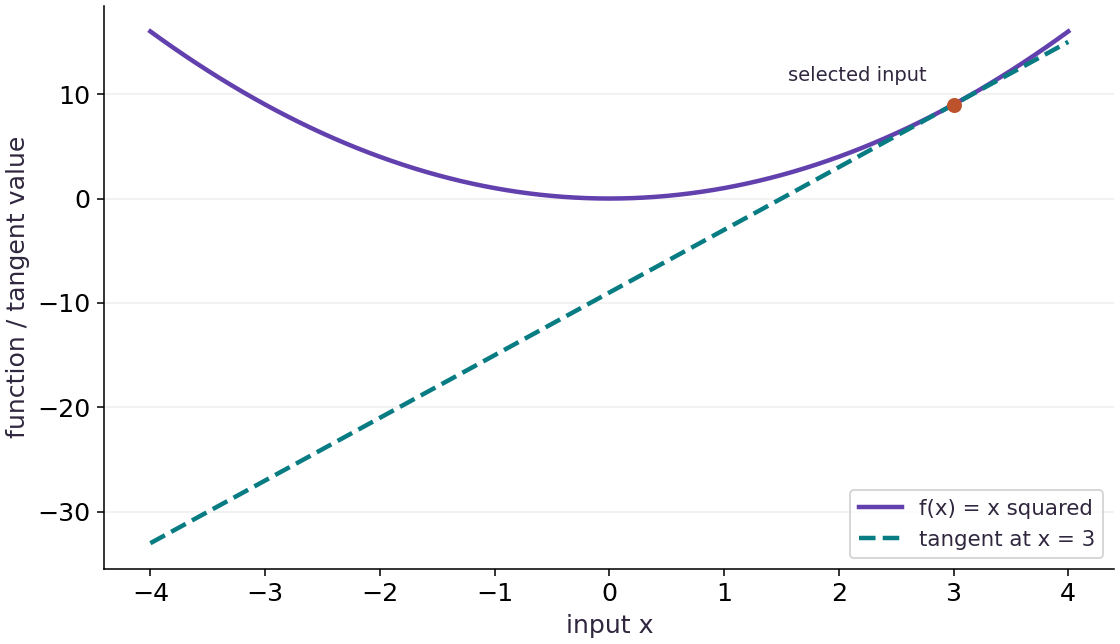

In [7]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The solid curve is $f(x)=x^2$. The dashed line is its tangent at the marked point $(3,9)$. The horizontal axis measures the input; the vertical axis shows either the function value or the tangent’s predicted value.

Near the marked point the two almost coincide. Farther away they separate: at $x=2$, the curve is $4$ and the tangent is $3$. At $x=0$, the curve is $0$, but the tangent has fallen to $-9$.

### Connect it to the computation

The derivative at $x=3$ is $6$, so the local prediction is $f(3+\Delta x)\approx9+6\Delta x$. The exact value also contains $(\Delta x)^2$. That omitted term explains why the approximation is good for small changes and increasingly poor for large ones.

The negative part of the dashed line does not mean a square became negative. It means a local linear approximation was extended beyond the neighborhood where it is useful. A gradient describes local change, not the complete function.

## Check the chain rule at three inputs

Predict: For $g(x)=(3x+1)^2$, predict the derivative at $-1$, $0$, and $2$. Explain why the sign changes.

In [8]:
# Experiment — Check the chain rule at three inputs: The inner derivative contributes a factor of 3.
def composed(x):
    # Return `(3.0 * x + 1.0) ** 2` to the caller.
    return (3. * x + 1.) ** 2
# Iterate over `point` to step through the computation:
for point in (-1., 0., 2.):
    # Differentiate the objective to obtain `observed` via automatic differentiation.
    observed = jax.grad(composed)(point)
    # Compute `expected` from `6. * (3. * point + 1.)`
    expected = 6. * (3. * point + 1.)
    # Print the observed values to compare against the expected result.
    print("chain rule:", point, float(observed))
    # Check numerical equivalence within tolerance: `jnp.allclose(observed, expected)`
    assert jnp.allclose(observed, expected)

Expected: The three derivatives are $-12$, $6$, and $42$.

The inner derivative contributes a factor of $3$. Omitting that factor is a chain-rule error; matching only one point can hide a wrong expression.

## Choose a finite-difference scale

Predict: For the float32 function $x^3$ at $x=3$, will shrinking $h$ forever keep improving the estimate? Run the sweep and compare with $27$.

In [9]:
# Experiment — Choose a finite-difference scale: A central difference has truncation error at larger h and...
def cubic32(x):
    # Return `x ** 3` to the caller.
    return x ** 3
# Construct `point` via `jnp.array(3., dtype=jnp.float32)`
point = jnp.array(3., dtype=jnp.float32)
# Iterate over `step` to step through the computation:
for step in (1e-1, 1e-2, 1e-3, 1e-5, 1e-7):
    # Compute `estimate` from `(cubic32(point + step) - cubic32(point - step)) / (2...`
    estimate = (cubic32(point + step) - cubic32(point - step)) / (2. * step)
    # Print the observed values to compare against the expected result.
    print("h / estimate / error:", step, float(estimate), float(jnp.abs(estimate - 27.)))
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(jax.grad(cubic32)(point), 27.)

Expected: The errors need not decrease monotonically. At sufficiently small $h$, rounding can erase the input change.

A central difference has truncation error at larger $h$ and cancellation/rounding error at very small $h$. The original numerical-estimate example used Python floats; this sweep deliberately uses a JAX float32 array. Do not silently compare their precision as if it were identical.

## Your exercise

Foundation · Define $f(x)=x^3$. Derive $f\prime(x)$, predict the values at $-2$, $0$, and $3$, then verify every prediction with JAX. Explain why the zero at $x=0$ is separate from a minimum.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.

**Step-by-step implementation plan:**
1. Return `x ** 3` to the caller.
2. Iterate over `point` to step through the computation:
3. Check numerical equivalence within tolerance: `jnp.allclose(jax.grad(cubic)(point), 3. * point ** 2)`
4. Assert invariant `cubic(-0.1) < cubic(0.) < cubic(0.1)` holds

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Foundation · Define f(x)=x^3.
def cubic(x):
    # Return `x ** 3` to the caller.
    return ...  # TODO: return computed result
# Iterate over `point` to step through the computation:
for point in (-2., 0., 3.):
    # Check numerical equivalence within tolerance: `jnp.allclose(jax.grad(cubic)(point), 3. * point ** 2)`
    assert jnp.allclose(jax.grad(cubic)(point), 3. * point ** 2)  # TODO: complete assertion check
# Assert invariant `cubic(-0.1) < cubic(0.) < cubic(0.1)` holds
assert cubic(-0.1)  # TODO: complete assertion check
```

In [10]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Foundation · Define f(x)=x^3.
# def cubic(x):
    # Return `x ** 3` to the caller.
#     return ...  # TODO: return computed result
# Iterate over `point` to step through the computation:
# for point in (-2., 0., 3.):
    # Check numerical equivalence within tolerance: `jnp.allclose(jax.grad(cubic)(point), 3. * point ** 2)`
#     assert jnp.allclose(jax.grad(cubic)(point), 3. * point ** 2)  # TODO: complete assertion check
# Assert invariant `cubic(-0.1) < cubic(0.) < cubic(0.1)` holds
# assert cubic(-0.1)  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [11]:
# Exercise solution: Foundation · Define f(x)=x^3.
def cubic(x):
    # Return `x ** 3` to the caller.
    return x ** 3
# Iterate over `point` to step through the computation:
for point in (-2., 0., 3.):
    # Check numerical equivalence within tolerance: `jnp.allclose(jax.grad(cubic)(point), 3. * point ** 2)`
    assert jnp.allclose(jax.grad(cubic)(point), 3. * point ** 2)
# Assert invariant `cubic(-0.1) < cubic(0.) < cubic(0.1)` holds
assert cubic(-0.1) < cubic(0.) < cubic(0.1)

## Differentiate the parameter you intended · Practice

For the prediction $\hat y=wx$, find the derivative with respect to $w$ and then with respect to $x$. Evaluate them at $w=2$ and $x=3$. Predict both answers before choosing `argnums`.

Hint: grad defaults to `argnums=0.` The other input remains an input to the transformed callable.

### How to write: Differentiate the parameter you intended — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.

**Step-by-step implementation plan:**
1. Return `weight * x` to the caller.
2. Verify that the numerical values match the expected reference within tolerance.
3. Check numerical equivalence within tolerance: `jnp.allclose(jax.grad(scalar_prediction, argnums=1)(2., 3.), 2.)`

**Starter code scaffold (fill in the TODOs):**

```python
# Differentiate the parameter you intended (Practice): A parameter gradient and an input sensitivity answer...
def scalar_prediction(weight, x):
    # Return `weight * x` to the caller.
    return ...  # TODO: return computed result
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(jax.grad(scalar_prediction, argnums=0)(2., 3.), 3.)  # TODO: complete assertion check
# Check numerical equivalence within tolerance: `jnp.allclose(jax.grad(scalar_prediction, argnums=1)(2., 3.), 2.)`
assert jnp.allclose(jax.grad(scalar_prediction, argnums=1)(2., 3.), 2.)  # TODO: complete assertion check
```

In [12]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Differentiate the parameter you intended (Practice): A parameter gradient and an input sensitivity answer...
# def scalar_prediction(weight, x):
    # Return `weight * x` to the caller.
#     return ...  # TODO: return computed result
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(jax.grad(scalar_prediction, argnums=0)(2., 3.), 3.)  # TODO: complete assertion check
# Check numerical equivalence within tolerance: `jnp.allclose(jax.grad(scalar_prediction, argnums=1)(2., 3.), 2.)`
# assert jnp.allclose(jax.grad(scalar_prediction, argnums=1)(2., 3.), 2.)  # TODO: complete assertion check

## Reference reasoning

A parameter gradient and an input sensitivity answer different questions even when they originate from the same function.

In [13]:
# Differentiate the parameter you intended (Practice): A parameter gradient and an input sensitivity answer...
def scalar_prediction(weight, x):
    # Return `weight * x` to the caller.
    return weight * x
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(jax.grad(scalar_prediction, argnums=0)(2., 3.), 3.)
# Check numerical equivalence within tolerance: `jnp.allclose(jax.grad(scalar_prediction, argnums=1)(2., 3.), 2.)`
assert jnp.allclose(jax.grad(scalar_prediction, argnums=1)(2., 3.), 2.)

## Repair an objective without hiding its meaning · Challenge

A function returns $[x^2,(x-2)^2]$. Explain why ordinary grad rejects it. Build a scalar objective using their mean, derive its derivative, and check $x=0$, $1$, and $2$. Would a sum have the same derivative magnitude?

Hint: Write the reduction as a mathematical function first: its mean is $x^2-2x+2$.

### How to write: Repair an objective without hiding its meaning — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.

**Step-by-step implementation plan:**
1. Return `jnp.array([x ** 2, (x - 2.0) ** 2])` to the caller.
2. Function `mean_cost(x)` implementing this stage's computation:
3. Return `jnp.mean(two_costs(x))` to the caller.
4. Iterate over `point` to step through the computation:
5. Verify that the numerical values match the expected reference within tolerance.

**Starter code scaffold (fill in the TODOs):**

```python
# Repair an objective without hiding its meaning (Challenge): Mean and sum agree on the minimizer here but differ by a...
def two_costs(x):
    # Return `jnp.array([x ** 2, (x - 2.0) ** 2])` to the caller.
    return ...  # TODO: return computed result
# Function `mean_cost(x)` implementing this stage's computation:
def mean_cost(x):
    # Return `jnp.mean(two_costs(x))` to the caller.
    return ...  # TODO: return computed result
# Iterate over `point` to step through the computation:
for point in (0., 1., 2.):
    # Verify that the numerical values match the expected reference within tolerance.
    assert jnp.allclose(jax.grad(mean_cost)(point), 2. * point - 2.)  # TODO: complete assertion check
    # Check numerical equivalence within tolerance: `jnp.allclose(jax.grad(lambda z: jnp.sum(two_costs(z)))(point), 2....`
    assert jnp.allclose(jax.grad(lambda z: jnp.sum(two_costs(z)))(point), 2. * jax.grad(mean_cost)(point))  # TODO: complete assertion check
```

In [14]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Repair an objective without hiding its meaning (Challenge): Mean and sum agree on the minimizer here but differ by a...
# def two_costs(x):
    # Return `jnp.array([x ** 2, (x - 2.0) ** 2])` to the caller.
#     return ...  # TODO: return computed result
# Function `mean_cost(x)` implementing this stage's computation:
# def mean_cost(x):
    # Return `jnp.mean(two_costs(x))` to the caller.
#     return ...  # TODO: return computed result
# Iterate over `point` to step through the computation:
# for point in (0., 1., 2.):
    # Verify that the numerical values match the expected reference within tolerance.
#     assert jnp.allclose(jax.grad(mean_cost)(point), 2. * point - 2.)  # TODO: complete assertion check
    # Check numerical equivalence within tolerance: `jnp.allclose(jax.grad(lambda z: jnp.sum(two_costs(z)))(point), 2....`
#     assert jnp.allclose(jax.grad(lambda z: jnp.sum(two_costs(z)))(point), 2. * jax.grad(mean_cost)(point))  # TODO: complete assertion check

## Reference reasoning

Mean and sum agree on the minimizer here but differ by a factor of two in gradient magnitude. Reducing output is a modeling choice, not just a syntax repair.

In [15]:
# Repair an objective without hiding its meaning (Challenge): Mean and sum agree on the minimizer here but differ by a...
def two_costs(x):
    # Return `jnp.array([x ** 2, (x - 2.0) ** 2])` to the caller.
    return jnp.array([x ** 2, (x - 2.) ** 2])
# Function `mean_cost(x)` implementing this stage's computation:
def mean_cost(x):
    # Return `jnp.mean(two_costs(x))` to the caller.
    return jnp.mean(two_costs(x))
# Iterate over `point` to step through the computation:
for point in (0., 1., 2.):
    # Verify that the numerical values match the expected reference within tolerance.
    assert jnp.allclose(jax.grad(mean_cost)(point), 2. * point - 2.)
    # Check numerical equivalence within tolerance: `jnp.allclose(jax.grad(lambda z: jnp.sum(two_costs(z)))(point), 2....`
    assert jnp.allclose(jax.grad(lambda z: jnp.sum(two_costs(z)))(point), 2. * jax.grad(mean_cost)(point))

## Checkpoint

For $f(x)=x^3$, JAX reports $f\prime(0)=0$. What can you conclude?

1. $x=0$ is a global minimum.
2. The first-order local slope is zero; optimality requires more evidence.
3. JAX has stopped differentiating because the output is zero.

## Diagnose

If grad reports a scalar-output error, inspect the output shape before adding an arbitrary reduction. If it reports an integer-input error, check the dtype of the differentiated argument. If a gradient is unexpectedly zero, evaluate the function at nearby inputs and verify argument selection. If finite differences disagree, record dtype and $h$, sweep $h$, and compare with an analytic test case. Each symptom calls for different evidence.

## Evidence

Keep predictions and analytic derivations at multiple inputs, the finite-difference step/error sweep with dtype, both argnums checks, and the scalar-objective repair. Explain why a zero gradient need not mark a minimum.

## Carry forward

- A derivative is a local sensitivity; a gradient transformation returns a callable.
- Autodiff applies the chain rule to program operations, while finite differences approximate with input perturbations.
- Scalar objective, input dtype, and differentiated argument are part of the contract.
- A stationary point and a minimum are different claims.

## Primary references

- [JAX: automatic differentiation](https://docs.jax.dev/en/latest/automatic-differentiation.html)
- [JAX: grad API and argument contract](https://docs.jax.dev/en/latest/_autosummary/jax.grad.html)